## Data Collection and Initial Exploration

This notebook performs the data collection, initial inspection, and exploratory analysis required for the project.

The objective is to gather authentic financial news data, benchmark misinformation data, and historical financial market data that will later be used for:
- misinformation detection
- synthetic financial misinformation generation
- market impact analysis

The collected datasets are stored in structured formats and prepared for later preprocessing and modelling stages.

**Data Collection Plan**

| Dataset | Source | Purpose | Output File |
|---|---|---|---|
| Real Financial News Articles | Yahoo Finance News Feed using yfinance | Authentic financial news corpus for NLP analysis and synthetic misinformation generation | financial_news.csv |
| Fake and Real News Dataset | Kaggle | Benchmark dataset for misinformation classification | fake_real_news.csv |
| Financial Market Data | Yahoo Finance API using yfinance | Historical market information for analysing stock reactions | market_data.csv |

The datasets are collected separately to maintain a clear distinction between:
- authentic financial information
- misinformation examples
- financial market behaviour

## Load Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# Create folders
project_path = ".."

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

## Collect Financial News Dataset

Financial news articles are collected through Yahoo Finance news feeds using the yfinance library.

In [ ]:
stock = yf.Ticker("AAPL")

articles = stock.news

print(type(articles))
print(len(articles))

articles[0]

In [ ]:
articles[0].keys()

dict_keys(['id', 'content'])

In [ ]:
# Expanded company list
# Using only 4 companies may not give enough articles.
tickers = [
    "AAPL",
    "MSFT",
    "TSLA",
    "NVDA",
    "AMZN",
    "GOOGL",
    "META",
    "NFLX",
    "AMD",
    "INTC",
    "JPM",
    "BAC",
    "GS",
    "MS",
    "C",
    "WMT",
    "COST",
    "HD",
    "TGT",
    "DIS",
    "UBER",
    "CRM",
    "ORCL",
    "KO",
    "PEP",
    "MCD",
    "NKE",
    "XOM",
    "CVX",
    "PFE",
    "JNJ",
    "PYPL",
    "SQ"
]

print("Total tickers:", len(tickers))

Total tickers: 33


In [ ]:
financial_news = []

for ticker in tickers:

    try:

        stock = yf.Ticker(ticker)

        articles = stock.news

        print(f"{ticker}: {len(articles)} articles")

        for article in articles:

            content = article.get("content", {})

            financial_news.append({

                "company_ticker":
                    ticker,

                "publication_date":
                    content.get("pubDate"),

                "title":
                    content.get("title"),

                "article_text":
                    content.get("summary"),

                "source":
                    content.get(
                        "provider",
                        {}
                    ).get(
                        "displayName",
                        "Unknown"
                    )

            })

    except Exception as e:

        print(
            f"Error collecting {ticker}:",
            e
        )

financial_news_df = pd.DataFrame(
    financial_news
)

print(
    "Financial News Shape:",
    financial_news_df.shape
)

AAPL: 10 articles
MSFT: 10 articles
TSLA: 10 articles
NVDA: 10 articles
AMZN: 10 articles
GOOGL: 10 articles
META: 10 articles
NFLX: 10 articles
AMD: 10 articles
INTC: 10 articles
JPM: 10 articles
BAC: 10 articles
GS: 10 articles
MS: 10 articles
C: 10 articles
WMT: 10 articles
COST: 10 articles
HD: 10 articles
TGT: 10 articles
DIS: 10 articles
UBER: 10 articles
CRM: 10 articles
ORCL: 10 articles
KO: 10 articles
PEP: 10 articles
MCD: 10 articles
NKE: 10 articles
XOM: 10 articles
CVX: 10 articles
PFE: 10 articles
JNJ: 10 articles
PYPL: 10 articles
SQ: 5 articles
Financial News Shape: (325, 5)


In [ ]:
# Quick Check
financial_news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   company_ticker    325 non-null    object
 1   publication_date  325 non-null    object
 2   title             325 non-null    object
 3   article_text      325 non-null    object
 4   source            325 non-null    object
dtypes: object(5)
memory usage: 12.8+ KB


In [ ]:
financial_news_df.head()

,company_ticker,publication_date,title,article_text,source
0,AAPL,2026-06-22T21:16:14Z,Memory's price surge threatens Apple's 'magic ...,Wall Street Journal technology reporter Rolfe ...,Yahoo Finance Video
1,AAPL,2026-06-23T09:26:00Z,"Ranking the ""Magnificent Seven"" From Most to L...","Among Nvidia, Alphabet, Apple, Microsoft, Amaz...",Motley Fool
2,AAPL,2026-06-23T06:55:02Z,Jim Cramer Discusses President Trump’s Big Ann...,We recently published Jim Cramer Discussed Exp...,Insider Monkey
3,AAPL,2026-06-23T04:32:29Z,Does Elon Musk represent a new form of capital...,"LONDON, June 23 (Reuters Breakingviews) - Foll...",Reuters
4,AAPL,2026-06-22T23:49:42Z,What Dell Stock's AI Order Book Revealed Befor...,"Before the stock more than tripled, the compan...",Trefis


The collected information includes:
- company ticker
- publication date
- article title
- article text
- news source

In [ ]:
financial_news_df.shape

(325, 5)

In [ ]:
financial_news_df.isnull().sum()

,0
company_ticker,0
publication_date,0
title,0
article_text,0
source,0


In [ ]:
# Save Raw Financial News
financial_news_df.to_csv(
    "data/raw/financial_news.csv",
    index=False
)

print("financial_news.csv saved")

financial_news.csv saved


## Download Fake News Dataset

The Kaggle Fake and Real News dataset is used as a benchmark dataset for supervised misinformation classification.

The dataset provides labelled examples of real and fake news articles.

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "clmentbisaillon/fake-and-real-news-dataset"
)

print(path)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
/kaggle/input/fake-and-real-news-dataset


In [ ]:
os.listdir(path)

['True.csv', 'Fake.csv']

In [ ]:
# Load the files
true_df = pd.read_csv(f"{path}/True.csv")
fake_df = pd.read_csv(f"{path}/Fake.csv")

In [ ]:
#Quick Check
print("True:", true_df.shape)
print("Fake:", fake_df.shape)

True: (21417, 4)
Fake: (23481, 4)


In [ ]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
# Create labels
true_df["label"] = "real"
fake_df["label"] = "fake"

In [ ]:
# Merge
fake_real_df = pd.concat(
    [true_df, fake_df],
    ignore_index=True
)

print(fake_real_df.shape)

(44898, 5)


In [ ]:
# Save Raw fake_real News
fake_real_df.to_csv(
    "data/raw/fake_real_news.csv",
    index=False
)

print("fake_real_news.csv saved")

fake_real_news.csv saved


## Download Market Data

Historical stock market data is collected from Yahoo Finance.

In [ ]:
market_tickers = [
    "AAPL",
    "MSFT",
    "TSLA",
    "NVDA",
    "AMZN",
    "GOOGL",
    "META",
    "NFLX",
    "AMD",
    "INTC",
    "JPM",
    "BAC",
    "GS",
    "MS",
    "C",
    "WMT",
    "COST",
    "HD",
    "TGT",
    "DIS",
    "UBER",
    "CRM",
    "ORCL",
    "KO",
    "PEP",
    "MCD",
    "NKE",
    "XOM",
    "CVX",
    "PFE",
    "JNJ",
    "PYPL",
    "SQ"
]

In [ ]:
# Download Data
market_data = []

for ticker in market_tickers:

    print("Downloading:", ticker)

    df = yf.download(
        ticker,
        start="2026-02-01",
        end="2026-06-30",
        progress=False
    )

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.reset_index()

    df["company_ticker"] = ticker

    market_data.append(df)

market_df = pd.concat(
    market_data,
    ignore_index=True
)

In [ ]:
# Daily Return
market_df["daily_return"] = (
    market_df
    .groupby("company_ticker")["Close"]
    .pct_change()
)

In [ ]:
# Volatility
market_df["volatility"] = (
    market_df
    .groupby("company_ticker")["daily_return"]
    .transform(
        lambda x: x.rolling(20).std()
    )
)

In [ ]:
# Future Return
market_df["future_return"] = (
    market_df
    .groupby("company_ticker")["daily_return"]
    .shift(-1)
)

In [ ]:
# Future Volume
market_df["future_volume"] = (
    market_df
    .groupby("company_ticker")["Volume"]
    .shift(-1)
)

In [ ]:
market_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            3200 non-null   datetime64[ns]
 1   Close           3200 non-null   float64       
 2   High            3200 non-null   float64       
 3   Low             3200 non-null   float64       
 4   Open            3200 non-null   float64       
 5   Volume          3200 non-null   float64       
 6   company_ticker  3200 non-null   object        
 7   Adj Close       0 non-null      float64       
 8   daily_return    3168 non-null   float64       
 9   volatility      2560 non-null   float64       
 10  future_return   3168 non-null   float64       
 11  future_volume   3168 non-null   float64       
dtypes: datetime64[ns](1), float64(10), object(1)
memory usage: 300.1+ KB


In [ ]:
market_df.head()

Price,Date,Close,High,Low,Open,Volume,company_ticker,Adj Close,daily_return,volatility,future_return,future_volume
0,2026-02-02,269.509277,269.988368,258.729288,259.547774,73913400.0,AAPL,NaN,NaN,NaN,-0.001963,64394700.0
1,2026-02-03,268.980286,271.375829,267.113728,268.700806,64394700.0,AAPL,NaN,-0.001963,NaN,0.026013,90545700.0
2,2026-02-04,275.977234,278.432694,271.785041,271.785041,90545700.0,AAPL,NaN,0.026013,NaN,-0.002098,52977400.0
3,2026-02-05,275.398346,278.981685,272.723323,277.614230,52977400.0,AAPL,NaN,-0.002098,NaN,0.008010,50453400.0
4,2026-02-06,277.604218,280.389052,276.416422,276.606072,50453400.0,AAPL,NaN,0.008010,NaN,-0.011660,44623400.0


The collected variables include:
- Open price
- High price
- Low price
- Closing price
- Trading volume

Daily returns are calculated to support later market impact analysis.

In [ ]:
market_df.shape

(3200, 12)

In [ ]:
# Save Raw Market Data
market_df.to_csv(
    "data/raw/market_data.csv",
    index=False
)

print("market_data.csv saved")

market_data.csv saved


## EDA

Exploratory analysis is performed to understand:
- data distribution
- class balance
- article characteristics
- market behaviour

In [ ]:
# Financial News - Initial EDA
financial_news_df["article_length"] = (
    financial_news_df["article_text"]
    .astype(str)
    .str.len()
)

print(
    "Articles:",
    len(financial_news_df)
)

print(
    "Date Range:",
    financial_news_df["publication_date"].min(),
    "to",
    financial_news_df["publication_date"].max()
)

Articles: 325
Date Range: 2026-02-09T20:52:00Z to 2026-06-23T10:00:00Z


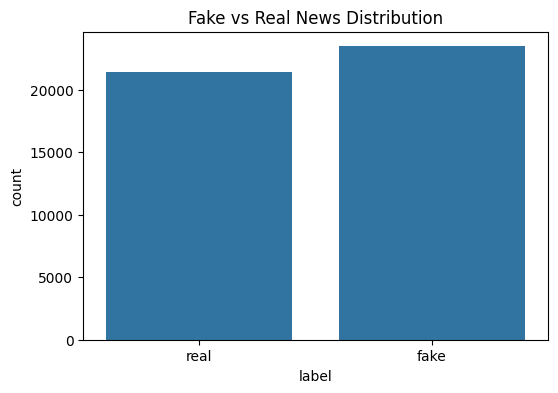

In [ ]:
# Fake vs Real Distribution - Initial EDA
plt.figure(figsize=(6,4))

sns.countplot(
    data=fake_real_df,
    x="label"
)

plt.title(
    "Fake vs Real News Distribution"
)

plt.show()

The Fake vs Real News Distribution chart shows a nearly balanced dataset, with slightly more fake news items than real ones, indicating a well‑represented sample for analysis.

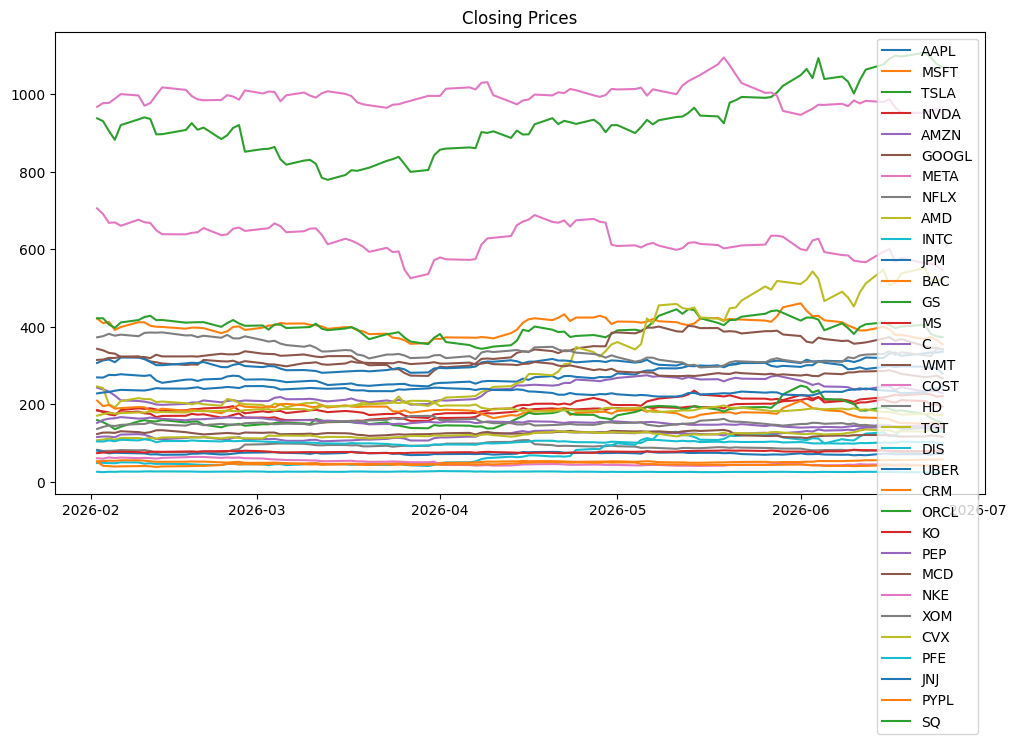

In [ ]:
# Closing Prices
plt.figure(figsize=(12,6))

for ticker in market_tickers:

    subset = market_df[
        market_df["company_ticker"] == ticker
    ]

    plt.plot(
        subset["Date"],
        subset["Close"],
        label=ticker
    )

plt.legend()

plt.title("Closing Prices")

plt.show()

The closing price distribution shows different valuation scales across companies.
This confirms the need to use normalized measures such as returns rather than
absolute prices for cross-company comparison.

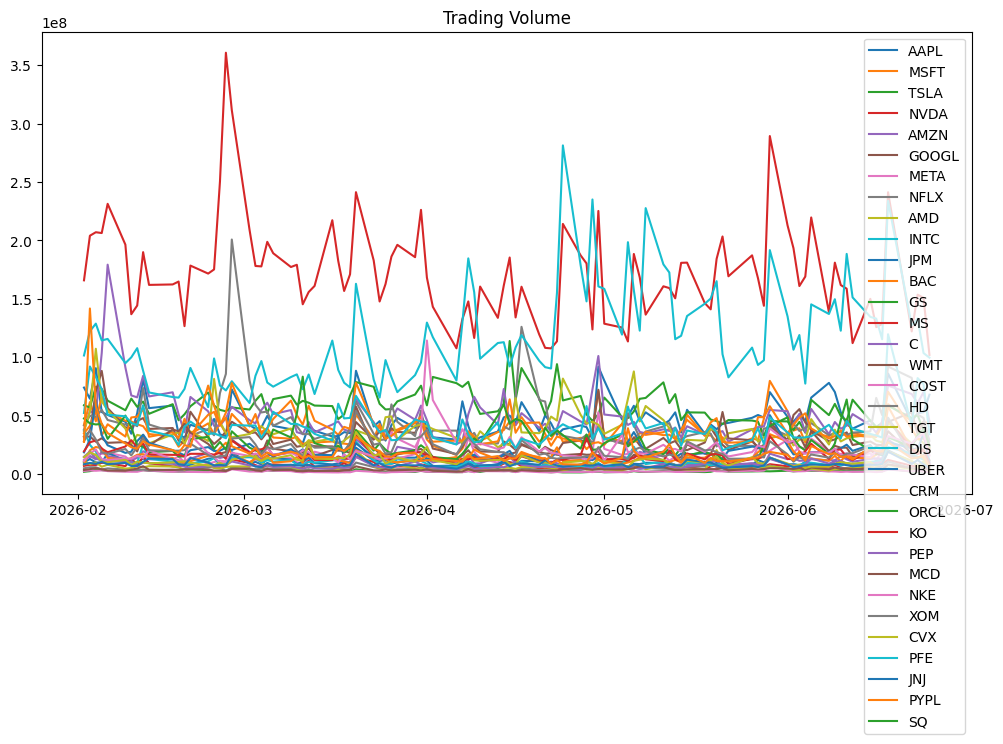

In [ ]:
# Trading Volume
plt.figure(figsize=(12,6))

for ticker in market_tickers:

    subset = market_df[
        market_df["company_ticker"] == ticker
    ]

    plt.plot(
        subset["Date"],
        subset["Volume"],
        label=ticker
    )

plt.legend()

plt.title("Trading Volume")

plt.show()

Trading volume differs substantially between companies, reflecting different
levels of market liquidity and investor activity.

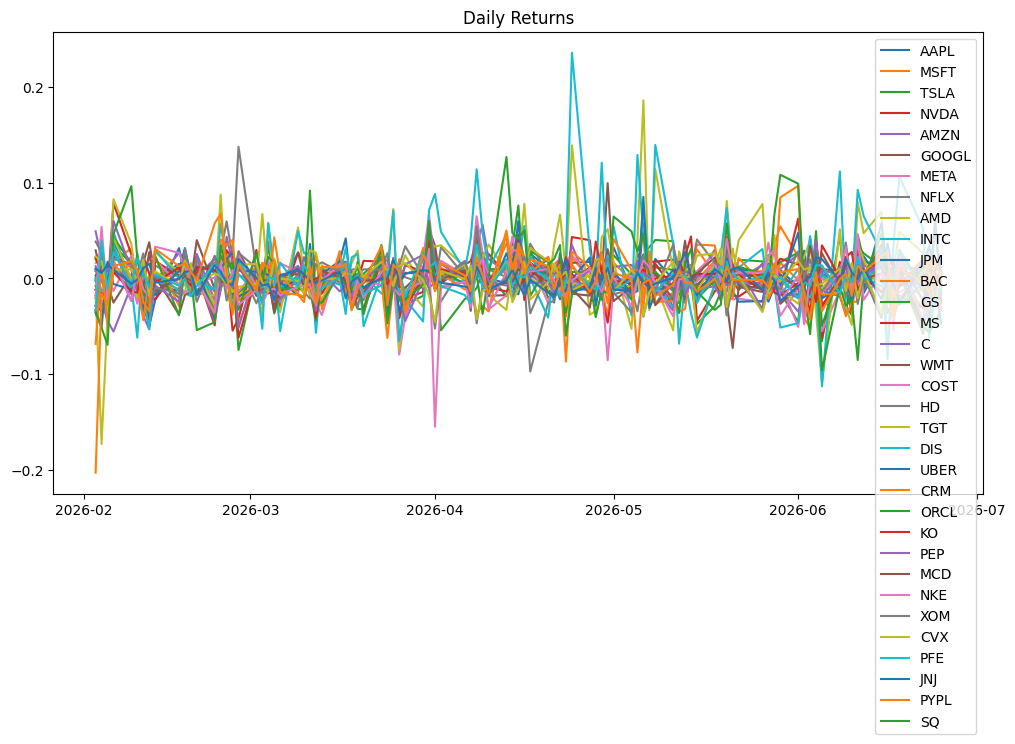

In [ ]:
# Daily Returns
plt.figure(figsize=(12,6))

for ticker in market_tickers:

    subset = market_df[
        market_df["company_ticker"] == ticker
    ]

    plt.plot(
        subset["Date"],
        subset["daily_return"],
        label=ticker
    )

plt.legend()

plt.title("Daily Returns")

plt.show()

Daily returns fluctuate around zero for most companies.
Occasional extreme movements indicate short-term market events,
which motivates analysing whether textual information can provide
additional predictive signals.

This notebook collected and inspected three datasets:

1. Financial news articles for NLP analysis
2. Fake and real news data for misinformation detection
3. Stock market data for financial impact analysis

The collected datasets are stored in structured formats and serve as
the foundation for preprocessing, synthetic misinformation generation,
model training, and market analysis in subsequent notebooks.